In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
# Data Generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
test_gen = ImageDataGenerator(rescale=1./255)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load Data
train_data = train_gen.flow_from_directory(
    '/content/drive/MyDrive/butterfly',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    '/content/drive/MyDrive/butterfly',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    '/content/drive/MyDrive/butterfly',
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'
)

Found 10912 images belonging to 3 classes.
Found 2727 images belonging to 3 classes.
Found 13639 images belonging to 3 classes.


In [5]:
# Load VGG16 — ImageNet weights, WITHOUT its top (classification) layers
vgg_base = VGG16(
    weights='imagenet',       # pretrained weights
    include_top=False,        # exclude VGG's own Dense layers
    input_shape=(128, 128, 3)
)

# Freeze all VGG16 layers — we only train our custom head
vgg_base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# Build model — VGG16 base +  custom classification head
model = models.Sequential([

    vgg_base,   # frozen feature extractor

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,077,187 (72.77 MB)

 Trainable params: 4,360,963 (16.64 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [7]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Train
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

Epoch 1/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 2989s 9s/step - accuracy: 0.9034 - loss: 0.4222 - val_accuracy: 0.9259 - val_loss: 0.3555
Epoch 2/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 61s 180ms/step - accuracy: 0.9245 - loss: 0.3487 - val_accuracy: 0.9267 - val_loss: 0.3335
Epoch 3/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 61s 178ms/step - accuracy: 0.9264 - loss: 0.3247 - val_accuracy: 0.9267 - val_loss: 0.3280
Epoch 4/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 62s 181ms/step - accuracy: 0.9265 - loss: 0.3017 - val_accuracy: 0.9267 - val_loss: 0.3380
Epoch 5/5
341/341 ━━━━━━━━━━━━━━━━━━━━ 70s 204ms/step - accuracy: 0.9268 - loss: 0.2835 - val_accuracy: 0.9267 - val_loss: 0.3566


In [9]:
# Evaluate
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

427/427 ━━━━━━━━━━━━━━━━━━━━ 61s 143ms/step - accuracy: 0.9272 - loss: 0.2450
Test Accuracy: 0.9271940588951111


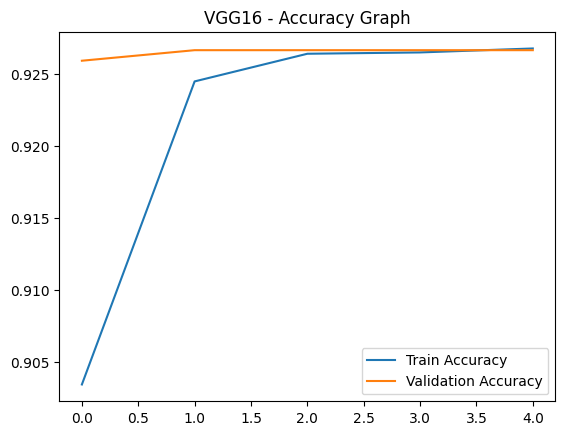

In [10]:
# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("VGG16 - Accuracy Graph")
plt.show()

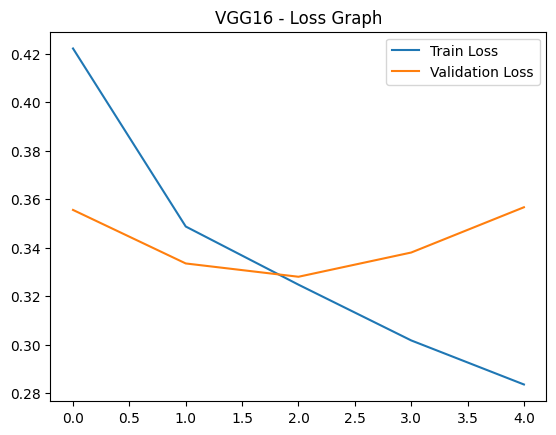

In [11]:
# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("VGG16 - Loss Graph")
plt.show()